In [26]:
# Importações

import pandas as pd
import matplotlib.pyplot as plt

print("Pronto!")

Pronto!


In [27]:
# Ler dados

df = pd.read_csv("2004-2021.tsv", sep = "\t")

df.head(5)

,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.19,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.89,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.18,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098
3,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.09,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143
4,2004-05-09,2004-05-15,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.05,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082


In [45]:
df.shape

(120823, 19)

In [28]:
# Ajuste e limpeza de dados

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df["data_inicial"] = pd.to_datetime(df["data_inicial"])

df["data_final"] = pd.to_datetime(df["data_final"])

In [29]:
# Romover acentos

import unicodedata

df["produto"] = df["produto"].apply(
lambda x: unicodedata.normalize("NFKD", x).encode("ASCII", "ignore").decode("utf-8"))

df.head(5)

,data_inicial,data_final,região,estado,produto,número_de_postos_pesquisados,unidade_de_medida,preço_médio_revenda,desvio_padrão_revenda,preço_mínimo_revenda,preço_máximo_revenda,margem_média_revenda,coef_de_variação_revenda,preço_médio_distribuição,desvio_padrão_distribuição,preço_mínimo_distribuição,preço_máximo_distribuição,coef_de_variação_distribuição
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.19,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.89,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO,192,R$/l,1.389,0.097,1.18,1.760,0.419,0.070,0.97,0.095,0.5614,1.161,0.098
3,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO DO SUL,ETANOL HIDRATADO,162,R$/l,1.262,0.070,1.09,1.509,0.432,0.055,0.83,0.119,0.5991,1.22242,0.143
4,2004-05-09,2004-05-15,NORDESTE,ALAGOAS,ETANOL HIDRATADO,103,R$/l,1.181,0.078,1.05,1.400,0.24,0.066,0.941,0.077,0.7441,1.0317,0.082


In [33]:
df["produto"].unique()

array(['ETANOL HIDRATADO', 'GASOLINA COMUM', 'GLP', 'GNV', 'OLEO DIESEL',
       'OLEO DIESEL S10', 'GASOLINA ADITIVADA'], dtype=object)

In [30]:
# Criando coluna "ano"

df["ano"] = df["data_inicial"].dt.year

print(df["ano"].max())

2021


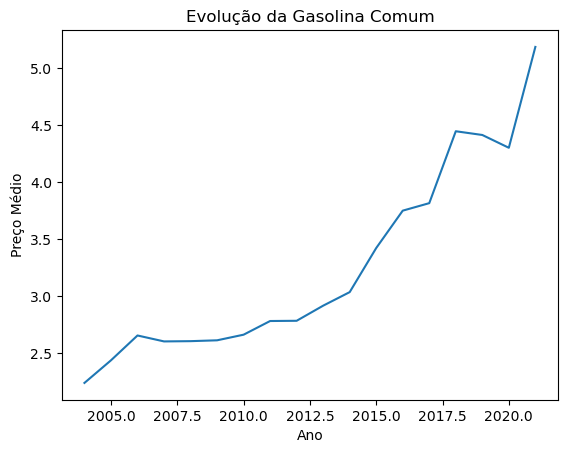

In [39]:
# Gasolina ao longo do tempo

gc = df[df["produto"] == "GASOLINA COMUM"]

seriegc = gc.groupby("ano")["preço_médio_revenda"].mean()

plt.figure()
plt.plot(seriegc.index, seriegc.values)
plt.xlabel("Ano")
plt.ylabel("Preço Médio")
plt.title("Evolução da Gasolina Comum")
plt.show()

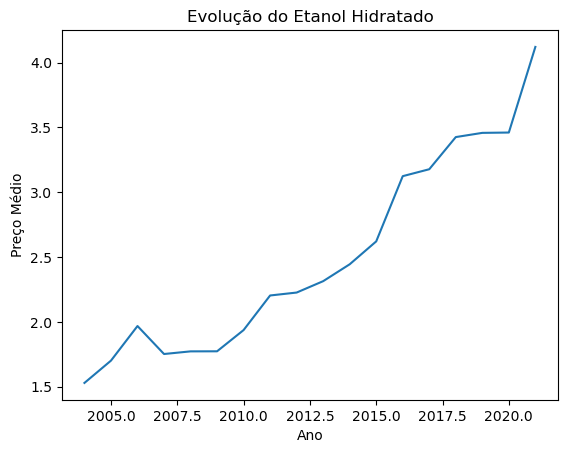

In [40]:
# Etanol ao longo do tempo

eh = df[df["produto"] == "ETANOL HIDRATADO"]

serieeh = eh.groupby("ano")["preço_médio_revenda"].mean()

plt.figure()
plt.plot(serieeh.index, serieeh.values)
plt.xlabel("Ano")
plt.ylabel("Preço Médio")
plt.title("Evolução do Etanol Hidratado")
plt.show()

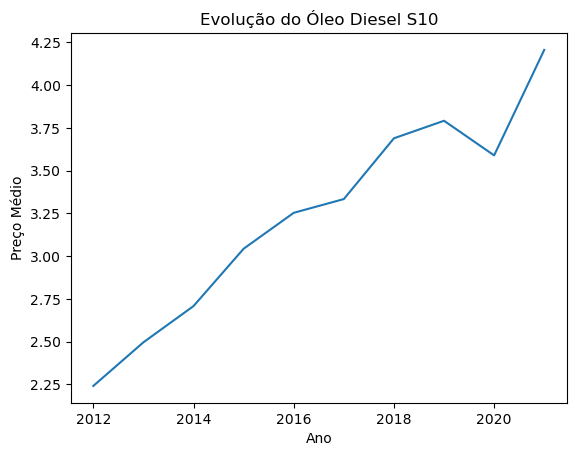

In [43]:
# Óleo Diesel S10 ao longo do tempo

ods10 = df[df["produto"] == "OLEO DIESEL S10"]

serieods10 = ods10.groupby("ano")["preço_médio_revenda"].mean()

plt.figure()
plt.plot(serieods10.index, serieods10.values)
plt.xlabel("Ano")
plt.ylabel("Preço Médio")
plt.title("Evolução do Óleo Diesel S10")
plt.show()

In [48]:
variacaogc = seriegc.pct_change() * 100

variacaogc

ano
2004          NaN
2005     8.848979
2006     8.933943
2007    -1.960308
2008     0.087600
2009     0.284824
2010     1.886150
2011     4.502131
2012     0.072879
2013     4.760074
2014     4.073541
2015    12.734958
2016     9.575850
2017     1.752510
2018    16.522968
2019    -0.735386
2020    -2.542589
2021    20.558904
Name: preço_médio_revenda, dtype: float64

In [50]:
variacaoeh = serieeh.pct_change() * 100

variacaoeh

ano
2004          NaN
2005    11.259368
2006    15.705833
2007   -10.977706
2008     1.164811
2009     0.029916
2010     9.247451
2011    13.786689
2012     1.026799
2013     3.946894
2014     5.632847
2015     7.229998
2016    19.212091
2017     1.710434
2018     7.810864
2019     0.948949
2020     0.075573
2021    19.092441
Name: preço_médio_revenda, dtype: float64

# Insight:

### O etanol apresenta forte correlação com a gasolina, mas maior volatilidade. Em alguns anos supera a variação da gasolina (ex: 2005), enquanto em outros acompanha de forma próxima (ex: 2021). Isso indica que, apesar de ambos reagirem a fatores macroeconômicos semelhantes, o etanol sofre influência adicional de fatores agrícolas, tornando sua variação menos previsível.

In [52]:
serie_et = eh.groupby("ano")["preço_médio_revenda"].mean()

seriegc.corr(serie_et)

0.9874205758836727

In [53]:
razao = serie_et / seriegc

razao

ano
2004    0.682620
2005    0.697736
2006    0.741111
2007    0.672946
2008    0.680188
2009    0.678460
2010    0.727478
2011    0.792112
2012    0.799662
2013    0.793455
2014    0.805343
2015    0.766018
2016    0.833382
2017    0.833037
2018    0.770754
2019    0.783832
2020    0.804889
2021    0.795099
Name: preço_médio_revenda, dtype: float64

In [54]:
razao.mean()

0.7587845475466536

In [55]:
razao.min()

0.6729457856086907

In [56]:
razao.max()

0.8333820858524559

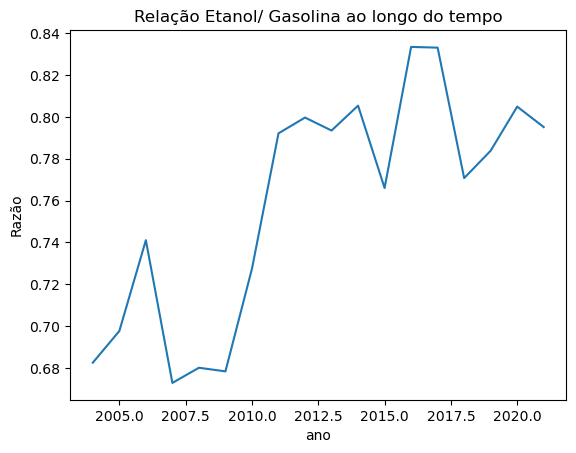

In [57]:
razao.plot()
plt.title("Relação Etanol/ Gasolina ao longo do tempo")
plt.ylabel("Razão")
plt.show()

In [58]:
razao[razao < 0.7]

ano
2004    0.682620
2005    0.697736
2007    0.672946
2008    0.680188
2009    0.678460
Name: preço_médio_revenda, dtype: float64

<AxesSubplot:xlabel='ano'>

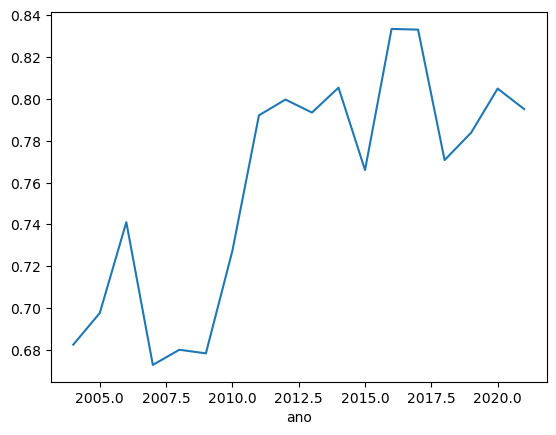

In [59]:
razao.plot()